# SOC Model Evaluation

## Open-loop testing

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


class NonNegConstraint(tf.keras.constraints.Constraint):
    def __call__(self, w):
        return tf.math.maximum(w, 0)

# Select features and target
features = ['tesBed.uModActual.y', # -1: Charge TES; 0: off; 1: Discharge TES; 2: Discharge chiller
            #'bChi.y', # Chiller on/off
            #'bIce.y', # TES on/off
            #'tesBed.occSch.occupied', # Ocuupied status
            'tesBed.iceTan.SOC_his1', # SOC
            #'tesBed.ave.y_his1', # Average Zonal temperature
            ]
target = ['tesBed.iceTan.SOC'] # total power of chiller + primary pump + secondary pump + AHU fan

##=====open-loop evaluation: the predicted SOC is used to predict the next-step SOC=======
## Note: open-loop testing is for continuous time-series data testing, the above testing data will be not suitable if it's random split
# Load the trained model
nn_model = tf.keras.models.load_model('./results_dnn/dnn_SOC_model.h5',
                                      custom_objects={'NonNegConstraint': NonNegConstraint}) # Reload the custom constraint when loading the model

# Load the dataset
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
timestep = 3600 # seconds in one time step
# Group by the interval of timestep (e.g., 1 hour) and pick the first row of each timestep 
data['time'] = (data['time'] // 3600) * 3600
data = data.groupby('time').last() # pick the last row of each timestep 
#data = data.groupby('time').first() # pick the first row of each timestep 

# Determine the index of predicted variable in the features list dynamically
updated_var_index = features.index('tesBed.iceTan.SOC_his1')

X = data[features].values
Y = data[target].values

# Determine dataset split point
split_point = int(0.5 * len(X))  # 80% split
x_train, x_test = X[:split_point], X[split_point:]
y_train, y_test = Y[:split_point], Y[split_point:]

# Define steps for open-loop testing
steps_per_hour = int(3600/timestep)
steps_per_day = int(24*3600/timestep)  # Number of steps for one day (288 for 5-minute intervals, 24 for 1-hour intervals)

# Define testing duration in days
num_days = 2 # Specify the number of days for testing
total_steps = int(num_days * steps_per_day) + 1

# Start day for testing (e.g., if the testing starts at the 80% split)
start_day = 0  # Define the starting day (you can modify this)
start_step = int(steps_per_day * start_day)

# Ensure there are enough data points after the start_step
if start_step + total_steps > len(x_test):
    raise ValueError("Not enough data points after the chosen start day for multi-day open-loop testing.")

# Initialize variables for open-loop testing
y_open_loop = []
y_true = []

# Initialize with the first value of SOC from the test dataset starting from start_step
predicted_SOC = x_test[start_step, updated_var_index]  # Starting with the first historical SOC,

# Open-loop testing loop for multi-day testing
for step in range(total_steps):
    # Get current inputs from the test dataset for the features except for 'tesBed.iceTan.SOC_his1'
    current_input = x_test[start_step + step:start_step + step + 1].copy()

    # Update the SOC_his1 feature with the predicted SOC for this time step
    current_input[0, updated_var_index] = predicted_SOC  # Update the historical SOC with the predicted one

    # Predict the next step SOC using the model
    predicted_SOC = nn_model.predict(current_input)[0][0]
    #predicted_SOC = min( nn_model.predict(current_input)[0][0], 0.99) # add bounds for predicted values

    # Store the predicted SOC and true SOC for comparison
    y_open_loop.append(predicted_SOC)
    y_true.append(y_test[start_step + step][0])  # Store the true SOC for the same step

# Convert results to numpy arrays for easier calculations
y_open_loop = np.array(y_open_loop)
y_true = np.array(y_true)

# Calculate the open-loop evaluation metrics (e.g., RMSE, R2 score)
mse_open_loop = np.mean((y_open_loop - y_true) ** 2)
rmse_open_loop = np.sqrt(mse_open_loop)
mean_true = np.mean(y_true)
cvrmse_open_loop = (rmse_open_loop / mean_true) * 100

# Print evaluation metrics
print(f"Open-loop RMSE: {rmse_open_loop:.3f}")
print(f"Open-loop CV(RMSE): {cvrmse_open_loop:.2f}%")

1/1 [==============================] - 0s 84ms/step
Open-loop RMSE: 0.030
Open-loop CV(RMSE): 3.34%


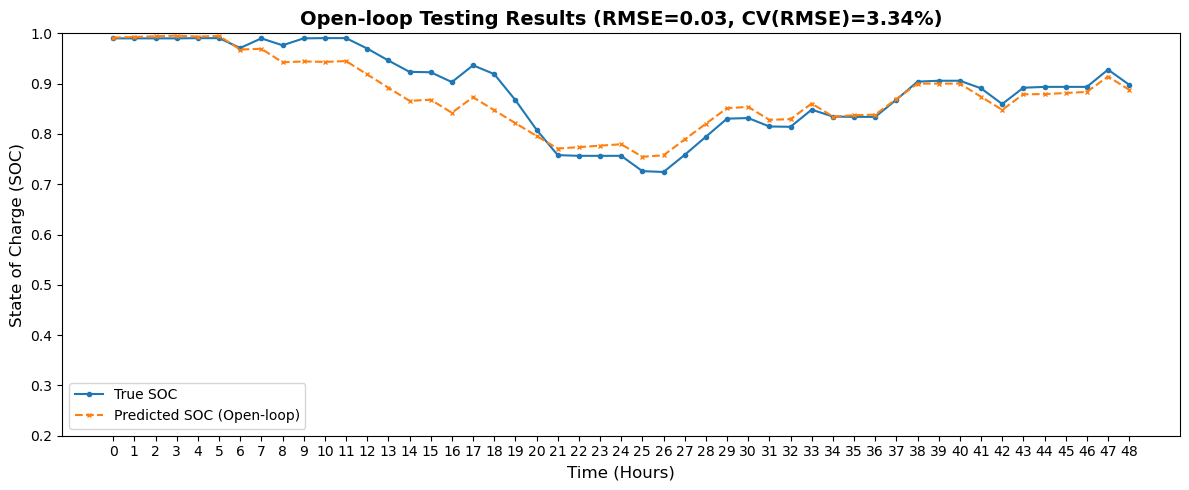

In [20]:
%matplotlib inline

# Plot the results with multi-day hourly intervals on the x-axis
plt.figure(figsize=(12, 5))

# Create x-axis labels for each hour across the total testing period
total_hours = total_steps // steps_per_hour  # Total number of hours for the testing period
hourly_indices = np.arange(0, total_steps, steps_per_hour)  # Indices for plotting hourly points
hour_labels = np.arange(total_hours)  # Labels for hours

# Plot the true SOC values and predicted SOC values
plt.plot(y_true, label='True SOC', marker='o', markersize=3)
plt.plot(y_open_loop, label='Predicted SOC (Open-loop)', linestyle='--', marker='x', markersize=3)

# Set the x-axis to display hourly intervals across multiple days
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('State of Charge (SOC)', fontsize=12)
plt.ylim(0.2,1)
plt.title(f'Open-loop Testing Results (RMSE={rmse_open_loop:.2f}, CV(RMSE)={cvrmse_open_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
#plt.grid(True)
plt.tight_layout()

# Save the plot and show
plt.savefig('results_dnn/open_loop_test_SOC.png', dpi=300)
#plt.show()

## Closed-loop testing

1/1 [==============================] - 0s 28ms/step
Closed-loop RMSE: 0.009
Closed-loop CV(RMSE): 1.01%


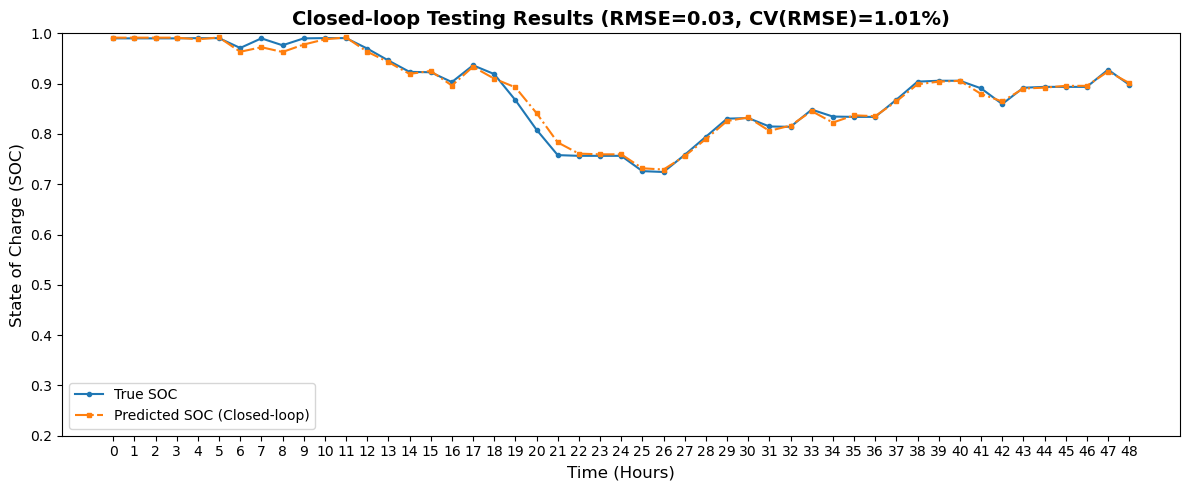

In [ ]:
# === Closed-loop Testing ===

# Reuse x_test, y_test, updated_var_index, start_step, total_steps from above

# Initialize closed-loop prediction list
y_closed_loop = []

for step in range(total_steps):
    # Copy current input features from test data
    current_input = x_test[start_step + step:start_step + step + 1].copy()

    # In closed-loop, use ground truth historical SOC (already present in data)
    # No need to update with predictions

    # Predict SOC using current input
    predicted_SOC = nn_model.predict(current_input)[0][0]

    # Store prediction
    y_closed_loop.append(predicted_SOC)

# Convert to numpy array
y_closed_loop = np.array(y_closed_loop)

# Compute metrics
mse_closed_loop = np.mean((y_closed_loop - y_true) ** 2)
rmse_closed_loop = np.sqrt(mse_closed_loop)
mean_true = np.mean(y_true)
cvrmse_closed_loop = (rmse_closed_loop / mean_true) * 100

# Print metrics
print(f"Closed-loop RMSE: {rmse_closed_loop:.3f}")
print(f"Closed-loop CV(RMSE): {cvrmse_closed_loop:.2f}%")

# === Closed-loop Results ===

plt.figure(figsize=(12, 5))

# Plot true SOC
plt.plot(y_true, label='True SOC', marker='o', markersize=3)

# Plot open-loop predictions
#plt.plot(y_open_loop, label='Predicted SOC (Open-loop)', linestyle='--', marker='x', markersize=3)

# Plot closed-loop predictions
plt.plot(y_closed_loop, label='Predicted SOC (Closed-loop)', linestyle='-.', marker='s', markersize=3)

# Format x-axis
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('State of Charge (SOC)', fontsize=12)
plt.ylim(0.2, 1)
plt.title(f'Closed-loop Testing Results (RMSE={rmse_open_loop:.2f}, CV(RMSE)={cvrmse_closed_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()

# Save and show figure
plt.savefig('./results_dnn/closed_loop_test_SOC.png', dpi=300)
plt.show()


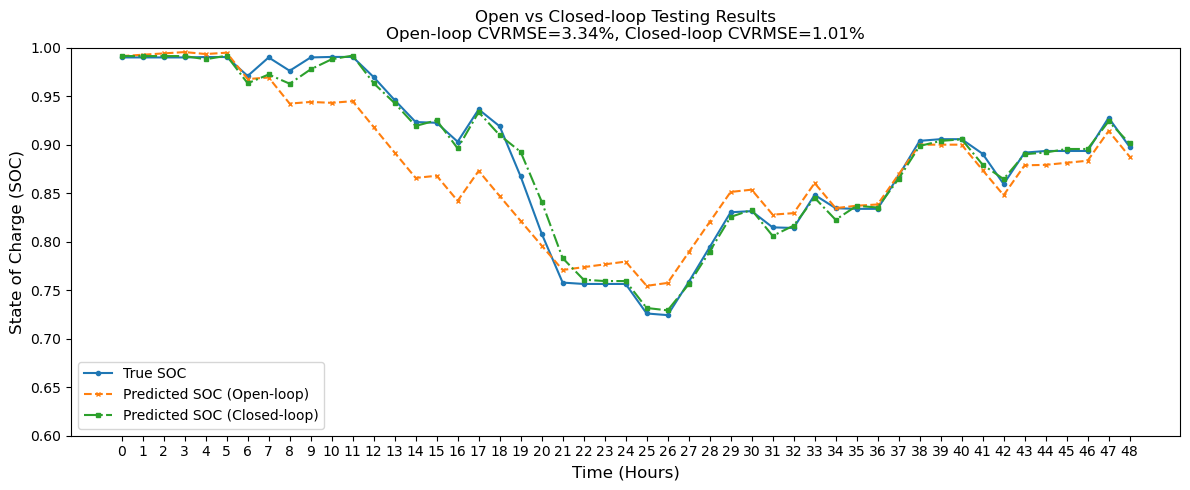

In [24]:
# === Compare Open-loop and Closed-loop Results ===

plt.figure(figsize=(12, 5))

# Plot true SOC
plt.plot(y_true, label='True SOC', marker='o', markersize=3)

# Plot open-loop predictions
plt.plot(y_open_loop, label='Predicted SOC (Open-loop)', linestyle='--', marker='x', markersize=3)

# Plot closed-loop predictions
plt.plot(y_closed_loop, label='Predicted SOC (Closed-loop)', linestyle='-.', marker='s', markersize=3)

# Format x-axis
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('State of Charge (SOC)', fontsize=12)
plt.ylim(0.6, 1)
plt.title(f'Open vs Closed-loop Testing Results\nOpen-loop CVRMSE={cvrmse_open_loop:.2f}%, Closed-loop CVRMSE={cvrmse_closed_loop:.2f}%')
plt.legend(loc='lower left')
plt.tight_layout()

# Save and show figure
plt.savefig('./results_dnn/open_vs_closed_loop_test_SOC.png', dpi=300)
plt.show()